In [2]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl
%matplotlib inline


In [3]:
## Echauffement

a = np.array([1,2,3])

#1) a est de forme (3) => a[:,None] est de forme (3,1)
# a est de forme (3) => a[None,:] est de forme (1,3)

#2) a[:, None] - a[None, :] => de forme (3,3) 
# on obtient le résultat de : [[1,1,1],[2,2,2],[3,3,3]] - [[1,2,3],[1,2,3],[1,2,3]]
print(a[:, None] - a[None, :])
print(np.array([[1,1,1],[2,2,2],[3,3,3]]) - np.array([[1,2,3],[1,2,3],[1,2,3]]))

# On a bien la même chose, on généralise : 
# RES[i,j]=a[i]-a[j]


#3) b est de forme (2,3)
# => b[:,None,:] est de forme (2,1,3)
# => b[:,:,None] est de forme (2,3,1)
# 
# => RES = b[:,None,:] - b[:,:,None] est de forme (2,3,3)
#
# RES[i,j,k] = b[:,None,:][i][1][k] - b[:,:,None][i][j][1]
#            = b[i][k] - b[i][j]



[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]
[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]


In [4]:
## Initialisation aléatoire

# les bornes pour le tirage au sort initial
mass_max = 3.
    
x_min, x_max = -10., 10.
y_min, y_max = -10., 10.

speed_max = 1.



def init_problem(N):
    """
    retourne un tuple masses, positions, speeds
    de formes resp.   (N,)    (2, N)     (2, N)
    tiré au sort dans les bornes définies ci-dessus
    """
    masses=np.random.uniform(0, mass_max, (N,))
    positions=np.random.uniform(np.array([[x_min],[y_min]]), np.array([[x_max],[y_max]]), (2,N))
    speeds=np.random.uniform(-speed_max, speed_max, (2,N))

    return masses, positions, speeds

print(init_problem(5))

(array([1.24980684, 2.25753201, 0.95095288, 0.76600099, 1.46395657]), array([[-6.6208548 , -4.10162027,  1.05585876,  8.46086248, -8.78847323],
       [-9.75833634,  6.37594576,  5.43096236,  6.39657062, -5.897258  ]]), array([[ 0.74583229,  0.64428066, -0.68505387,  0.36425352, -0.71177487],
       [-0.68613472,  0.20334097, -0.78962013, -0.41537239, -0.31905272]]))


In [5]:
## Initialisation reproductible

def init3():
    # first element is sun-like: heavy, at the center, and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds



In [6]:
## Les forces


def forces(masses, positions, G=1.0):
    """
    returns an array of shape (2,  N)
    that contains the force felt by each mass from all the others
    G is the Newton constant and by default is set to 1 
    (we have abstract units anyway)
    """

    diff=positions[:,:,None]-positions[:,None,:]
    dist=np.linalg.norm(diff, axis=0)
    
    np.fill_diagonal(dist,np.inf)
    
    coeff=G*masses[:,None]*masses[None,:]
    C=coeff[None,:,:]
        
    F=np.sum(C*diff/(dist**3), axis=1)

    
    return F

print(forces(init3()[0],init3()[1]))


[[ 0.         -0.12257258  0.12257258]
 [ 0.         -0.02451452  0.02451452]]


In [7]:
## Le simulateur

def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    """
    should return the positions across time
    so an array of shape (nb_steps, 2, N)
    optional dt is the time step
    """
    N=len(masses)
    dim=len(positions)
    res=np.zeros((nb_steps,dim,N))

    m=masses[None,:]
    res[0]=positions

    for i in range(nb_steps):
        F=forces(masses,positions)
        a=F/m
        speeds=speeds+a*dt
        positions=positions+speeds*dt
        res[i]=positions
    return res

print(simulate(init3()[0],init3()[1],init3()[2]))



[[[ 0.          4.89877427 -4.89877427]
  [ 0.          0.99975485 -0.99975485]]

 [[ 0.          4.79627468 -4.79627468]
  [ 0.          0.99924973 -0.99924973]]

 [[ 0.          4.69244953 -4.69244953]
  [ 0.          0.99846845 -0.99846845]]

 [[ 0.          4.58724324 -4.58724324]
  [ 0.          0.99739329 -0.99739329]]

 [[ 0.          4.48059587 -4.48059587]
  [ 0.          0.99600479 -0.99600479]]

 [[ 0.          4.37244262 -4.37244262]
  [ 0.          0.99428155 -0.99428155]]

 [[ 0.          4.26271324 -4.26271324]
  [ 0.          0.99219989 -0.99219989]]

 [[ 0.          4.15133136 -4.15133136]
  [ 0.          0.98973361 -0.98973361]]

 [[ 0.          4.03821371 -4.03821371]
  [ 0.          0.98685348 -0.98685348]]

 [[ 0.          3.92326914 -3.92326914]
  [ 0.          0.9835269  -0.9835269 ]]

 [[ 0.          3.80639758 -3.80639758]
  [ 0.          0.97971724 -0.97971724]]

 [[ 0.          3.68748865 -3.68748865]
  [ 0.          0.97538319 -0.97538319]]

 [[ 0.          

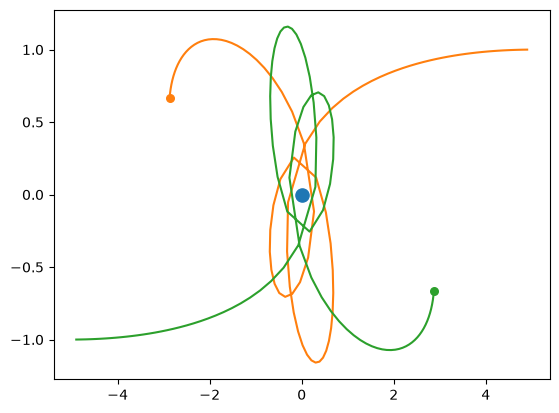

In [16]:
## Dessiner



def draw(simulation, masses, colors=None, scale=10.):
    """
    takes as input the result of simulate() above,
    and draws the nb_steps positions of each of the N bodies
    ideally it should return a matplotlib Axes object

    one can provide a collection of N colors to use for each body
    if not provided this is randomized

    also the optional scale parameter is used as a constant
    multiplier to obtain the final size of each dot on the figure
    """
    fig,ax=plt.subplots()
    for i in range(len(masses)):
        X,Y=simulation[:,:,i].T[0],simulation[:,:,i].T[1]
        if colors is not None:
            print(colors[i])
            plt.plot(X,Y, color=colors[i])
            ax.scatter(X[-1],Y[-1],s=30*masses[i], color=colors[i])
        else:
            plt.plot(X,Y)
            ax.scatter(X[-1],Y[-1],s=30*masses[i])

    plt.show()


    pass

draw(simulate(init3()[0],init3()[1],init3()[2]),init3()[0])

In [17]:
# liste de jolies couleurs :)

colors3 = np.array([
    (32, 32, 32),
    (228, 90, 146),
    (111, 0, 255),
]) / 255

print(type(colors3))


<class 'numpy.ndarray'>


[0.1254902 0.1254902 0.1254902]
[0.89411765 0.35294118 0.57254902]
[0.43529412 0.         1.        ]


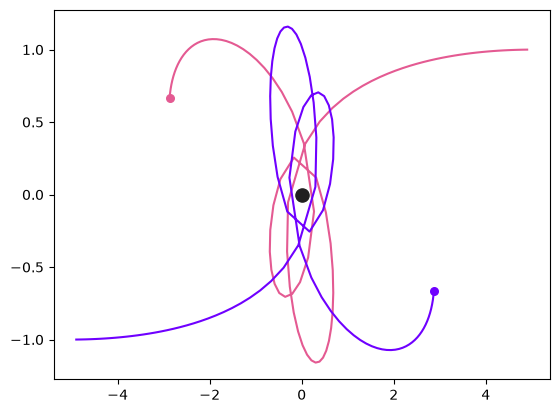

In [18]:
## On assemble tout 


masses, positions, speeds = init3()
draw(simulate(masses, positions, speeds), masses, colors=colors3)


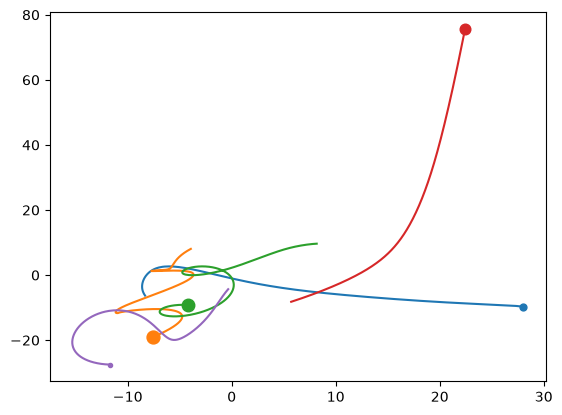

<Figure size 640x480 with 0 Axes>

In [25]:
m5, p5, s5 = init_problem(5)
sim5 = simulate(m5, p5, s5, nb_steps=1000)
draw(sim5, m5, scale=3);
plt.savefig("random5.png")


TypeError: 'PathCollection' object is not iterable

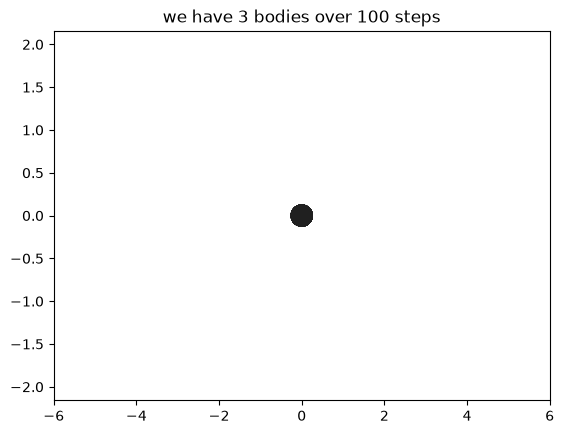

In [31]:

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate(simulation, masses, colors=None, scale=5., interval=50):
    nb_steps, _, N = simulation.shape
    colors = (colors if colors is not None
              else np.random.uniform(0.3, 1., size=(N, 3)))

    fig, ax = plt.subplots()
    ax.set_title(f"we have {N} bodies over {nb_steps} steps")

    ax.set_xlim(simulation[:, 0].min() - 1, simulation[:, 0].max() + 1)
    ax.set_ylim(simulation[:, 1].min() - 1, simulation[:, 1].max() + 1)

    scat = ax.scatter(np.zeros(N), np.zeros(N), c=colors, s=(masses*scale)**2)

    def init():
        scat.set_offsets(np.zeros((nb_steps, N)))
        return scat

    def update(step):
        x, y = simulation[step]
        scat.set_offsets(np.c_[x, y])
        return scat

    animation = FuncAnimation(
        fig, update, frames=nb_steps,
        init_func=init, blit=True, interval=interval
    )
    plt.close()
    return animation

def animate_from_file(filename):
    simulation = np.loadtxt(filename).reshape((100, 2, 3))
    animation = animate(simulation, masses, colors=colors3)
    return HTML(animation.to_jshtml())

animate_from_file("init3-simu-1.txt")

